In [37]:
!pip install opendatasets --quiet


In [38]:
import opendatasets as od

In [39]:
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)


In [40]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd


In [41]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [42]:
data_df = pd.read_csv('/content/rice-type-classification/riceClassification.csv')

In [43]:
print(data_df.head())

   id  Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0   1  4537        92.229316        64.012769      0.719916        4677   
1   2  2872        74.691881        51.400454      0.725553        3015   
2   3  3048        76.293164        52.043491      0.731211        3132   
3   4  3073        77.033628        51.928487      0.738639        3157   
4   5  3693        85.124785        56.374021      0.749282        3802   

   EquivDiameter    Extent  Perimeter  Roundness  AspectRation  Class  
0      76.004525  0.657536    273.085   0.764510      1.440796      1  
1      60.471018  0.713009    208.317   0.831658      1.453137      1  
2      62.296341  0.759153    210.012   0.868434      1.465950      1  
3      62.551300  0.783529    210.657   0.870203      1.483456      1  
4      68.571668  0.769375    230.332   0.874743      1.510000      1  


In [44]:
data_df.isnull().sum()

,0
id,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0


In [45]:
data_df.dropna(inplace =True) #inplace: có nghĩa là thực hiện thay đổi trên bản gốc chứ không tạo ra bản sao
data_df.drop(['id'], axis = 1, inplace =True)
print(data_df.shape)

(18185, 11)


In [46]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [47]:
print(data_df["Class"].unique())

[1 0]


In [48]:
print(data_df['ConvexArea'].unique())

[4677 3015 3132 ... 8260 7699 7058]


In [49]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [50]:
original_df = data_df.copy()
for column in data_df.columns:
  data_df[column] = data_df[column]/ data_df[column].abs().max()

In [51]:
print(data_df.columns)

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')


In [52]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [53]:
import numpy as np
##Cach 1
X = np.array(data_df.drop(["Class"],axis =1))
Y= np.array(data_df["Class"])

In [54]:
#Cach 2
X = np.array(data_df.iloc[:,:-1])
Y = np.array(data_df.iloc[:,-1])

In [55]:
print(X[:5])


[[0.44436827 0.50340371 0.77543522 0.7446585  0.42487282 0.66660953
  0.74166052 0.5370287  0.844997   0.36831616]
 [0.28129285 0.40768133 0.62265269 0.75048874 0.27389172 0.53037048
  0.80423032 0.40966075 0.91921498 0.37147093]
 [0.29853085 0.41642141 0.63044229 0.75634138 0.28452035 0.54637977
  0.85627819 0.41299402 0.95986205 0.37474651]
 [0.30097943 0.42046299 0.62904915 0.76402442 0.28679142 0.54861592
  0.88377241 0.41426243 0.96181789 0.37922161]
 [0.36170421 0.46462594 0.68290127 0.77503309 0.34538517 0.6014185
  0.86780778 0.45295382 0.96683604 0.38600721]]


In [56]:
print(Y[:5])

[1. 1. 1. 1. 1.]


In [57]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)

In [58]:
X_test,X_val,Y_test,Y_val = train_test_split(X_test,Y_test,test_size = 0.5)

In [59]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(14548, 10)
(1818, 10)
(1819, 10)


In [60]:
class dataset(Dataset) :
  def __init__(self,X,Y):
    self.X = torch.tensor(X,dtype = torch.float32).to(device)
    self.Y =torch.tensor(Y,dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self,index):
    return self.X[index], self.Y[index]


In [61]:
training_data = dataset(X_train,Y_train)
validation_data = dataset(X_val,Y_val)
test_data = dataset(X_test,Y_test)

In [62]:
train_dataloader =DataLoader(training_data, batch_size=32,shuffle= True)
validation_dataloader = DataLoader(validation_data,batch_size=32, shuffle = True)
test_dataloader = DataLoader(test_data,batch_size=32, shuffle =True)

In [63]:
for x,y in train_dataloader:
  print(x)
  print("="*50)
  print(y)
  break

tensor([[0.6219, 0.8755, 0.6169, 0.9809, 0.5918, 0.7886, 0.7832, 0.6943, 0.7076,
         0.8052],
        [0.7132, 0.8903, 0.7048, 0.9663, 0.6796, 0.8445, 0.8252, 0.7235, 0.7473,
         0.7167],
        [0.8676, 0.8733, 0.8686, 0.9247, 0.8204, 0.9314, 0.8107, 0.7455, 0.8561,
         0.5704],
        [0.7689, 0.7366, 0.9139, 0.8577, 0.7257, 0.8768, 0.6889, 0.6699, 0.9397,
         0.4573],
        [0.5615, 0.8057, 0.6125, 0.9718, 0.5352, 0.7493, 0.8460, 0.6508, 0.7270,
         0.7462],
        [0.4117, 0.7233, 0.4947, 0.9840, 0.3897, 0.6416, 0.5659, 0.5589, 0.7227,
         0.8295],
        [0.9149, 0.8925, 0.8911, 0.9238, 0.8676, 0.9565, 0.6626, 0.7708, 0.8445,
         0.5682],
        [0.6683, 0.8851, 0.6616, 0.9739, 0.6404, 0.8175, 0.5668, 0.7333, 0.6815,
         0.7590],
        [0.5505, 0.7658, 0.6311, 0.9604, 0.5247, 0.7420, 0.7699, 0.6301, 0.7604,
         0.6884],
        [0.7154, 0.8766, 0.7125, 0.9625, 0.6776, 0.8458, 0.5868, 0.7130, 0.7717,
         0.6979],
        [0

In [64]:
class Model(nn.Module):
  def __init__ (self):
    super(Model, self).__init__()
    self.input_layer = nn.Linear(X.shape[1], 64)
    self.relu = nn.ReLU() # Add ReLU activation
    self.linear =nn.Linear(64,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.input_layer(x)
    x = self.relu(x) # Apply ReLU after the first linear layer
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

model = Model().to(device)

In [65]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             704
              ReLU-2                   [-1, 64]               0
            Linear-3                    [-1, 1]              65
           Sigmoid-4                    [-1, 1]               0
Total params: 769
Trainable params: 769
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [66]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr= 1e-3)

In [67]:
total_loss_train_plot = []
total_accuracy_train_plot = []

total_loss_validation_plot = []
total_accuracy_validation_plot = []

epochs = 10

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_validation = 0
    total_loss_validation = 0

    model.train()
    for data in train_dataloader:
        inputs, label = data
        label = label.float()

        prediction = model(inputs).squeeze(1)
        # Handle potential NaN/inf values and clamp predictions to a valid range for BCELoss
        prediction = torch.nan_to_num(prediction, nan=0.5, posinf=1.0, neginf=0.0)
        prediction = torch.clamp(prediction, min=1e-7, max=1-1e-7)

        optimizer.zero_grad()
        batch_loss = criterion(prediction, label)
        batch_loss.backward()
        optimizer.step()

        total_loss_train += batch_loss.item()
        acc = (prediction.round() == label).sum().item()
        total_acc_train += acc

    model.eval()
    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data
            labels = labels.float()

            prediction = model(inputs).squeeze(1)
            # Handle potential NaN/inf values and clamp predictions to a valid range for BCELoss
            prediction = torch.nan_to_num(prediction, nan=0.5, posinf=1.0, neginf=0.0)
            prediction = torch.clamp(prediction, min=1e-7, max=1-1e-7)

            batch_loss = criterion(prediction, labels)

            total_loss_validation += batch_loss.item()
            acc = (prediction.round() == labels).sum().item()
            total_acc_validation += acc

    avg_train_loss = total_loss_train / len(train_dataloader)
    avg_val_loss = total_loss_validation / len(validation_dataloader)

    train_acc = total_acc_train / len(training_data) * 100
    val_acc = total_acc_validation / len(validation_data) * 100

    total_loss_train_plot.append(round(avg_train_loss, 4))
    total_loss_validation_plot.append(round(avg_val_loss, 4))

    total_accuracy_train_plot.append(round(train_acc, 4))
    total_accuracy_validation_plot.append(round(val_acc, 4))

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_acc:.4f}%")
    print(f"           Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {val_acc:.4f}%")

Epoch 1 | Train Loss: 0.4557 | Train Accuracy: 90.8853%
           Validation Loss: 0.2081 | Validation Accuracy: 98.1308%
Epoch 2 | Train Loss: 0.1249 | Train Accuracy: 98.3503%
           Validation Loss: 0.0835 | Validation Accuracy: 98.8455%
Epoch 3 | Train Loss: 0.0687 | Train Accuracy: 98.5290%
           Validation Loss: 0.0574 | Validation Accuracy: 98.9555%
Epoch 4 | Train Loss: 0.0539 | Train Accuracy: 98.5840%
           Validation Loss: 0.0471 | Validation Accuracy: 99.0104%
Epoch 5 | Train Loss: 0.0482 | Train Accuracy: 98.5840%
           Validation Loss: 0.0425 | Validation Accuracy: 98.9555%
Epoch 6 | Train Loss: 0.0452 | Train Accuracy: 98.5703%
           Validation Loss: 0.0390 | Validation Accuracy: 99.0104%
Epoch 7 | Train Loss: 0.0433 | Train Accuracy: 98.5634%
           Validation Loss: 0.0374 | Validation Accuracy: 98.9555%
Epoch 8 | Train Loss: 0.0427 | Train Accuracy: 98.6184%
           Validation Loss: 0.0381 | Validation Accuracy: 98.8455%
Epoch 9 | Train 

In [70]:
with torch.no_grad():
  total_loss_test =0
  total_acc_test=0
  for data in test_dataloader:
    inputs, labels = data
    prediction = model(inputs).squeeze(1)
    batch_loss_test = criterion(prediction,labels)

    total_loss_test += batch_loss_test.item() #Tra ve 1 tensor nen can them item() vao
    acc = (prediction.round()== labels).sum().item()
    total_acc_test += acc
  avg_loss_test = total_loss_test / len(test_dataloader)
  avg_acc_test = total_acc_test / len(test_data) * 100
  print(f'''loss_test: {round(avg_loss_test,4)}        acc_test: {round(avg_acc_test,4)}%''')

loss_test: 0.0541        acc_test: 98.4048%


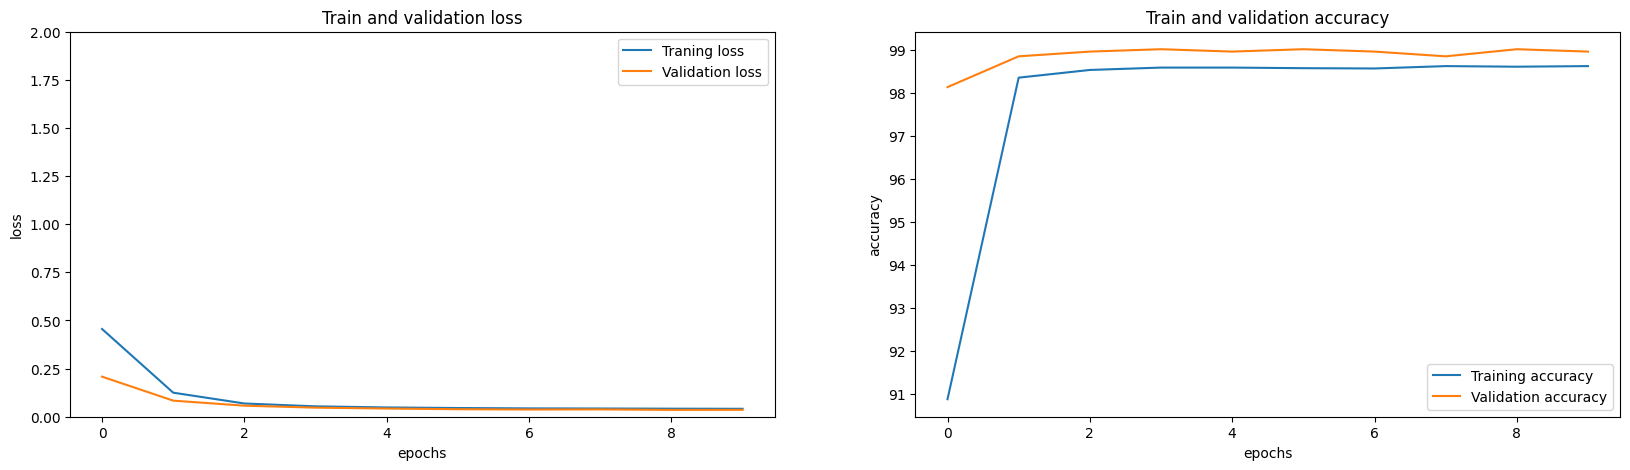

In [77]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
axs[0].plot(total_loss_train_plot, label='Traning loss')
axs[0].plot(total_loss_validation_plot, label='Validation loss')
axs[0].set_title('Train and validation loss')
axs[0].set_xlabel('epochs')
axs[0].set_ylabel('loss')
axs[0].set_ylim((0, 2))
axs[0].legend()

axs[1].plot(total_accuracy_train_plot, label='Training accuracy')
axs[1].plot(total_accuracy_validation_plot, label='Validation accuracy')
axs[1].set_title('Train and validation accuracy')
axs[1].set_xlabel('epochs')
axs[1].set_ylabel('accuracy')
axs[1].legend()